In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import chi2_contingency
import matplotlib.patches as mpatches
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


df = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/sample_submission.csv')
id_test = test['id']
x_train, x_valid = train_test_split(df, test_size = 0.2, random_state=42)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e1/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e1/train.csv
/kaggle/input/competitions/playground-series-s4e1/test.csv


In [2]:
# Setting for better plots
sns.set_style("darkgrid")    
sns.set_palette(["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"])

In [3]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/train.csv')
df.sample()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
125997,125997,15690670,Hsueh,559,France,Male,31.0,3,0.0,2,1.0,1.0,106864.8,0


In [4]:
print(x_train['Exited'].value_counts(normalize=True))

Exited
0    0.78818
1    0.21182
Name: proportion, dtype: float64


### ID/ Customer Id/ Surname

In [5]:
def drop_useless_feature(df):
    return df.drop(['id', 'CustomerId', 'Surname'], axis=1)

In [6]:
x_train = drop_useless_feature(x_train)
x_valid = drop_useless_feature(x_valid)
test = drop_useless_feature(test)
x_train.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
81096,659,France,Female,39.0,6,0.00,2,1.0,1.0,10063.75,0
23970,729,Germany,Male,36.0,4,152899.24,2,1.0,0.0,185580.89,0
9013,691,Spain,Male,43.0,6,0.00,2,1.0,1.0,162697.09,0
70119,707,France,Male,37.0,2,0.00,2,1.0,0.0,53585.16,0
36087,679,France,Male,44.0,4,0.00,2,1.0,1.0,129984.20,0


### Geography/ Gender/ HasCrCard/ ActiveMember

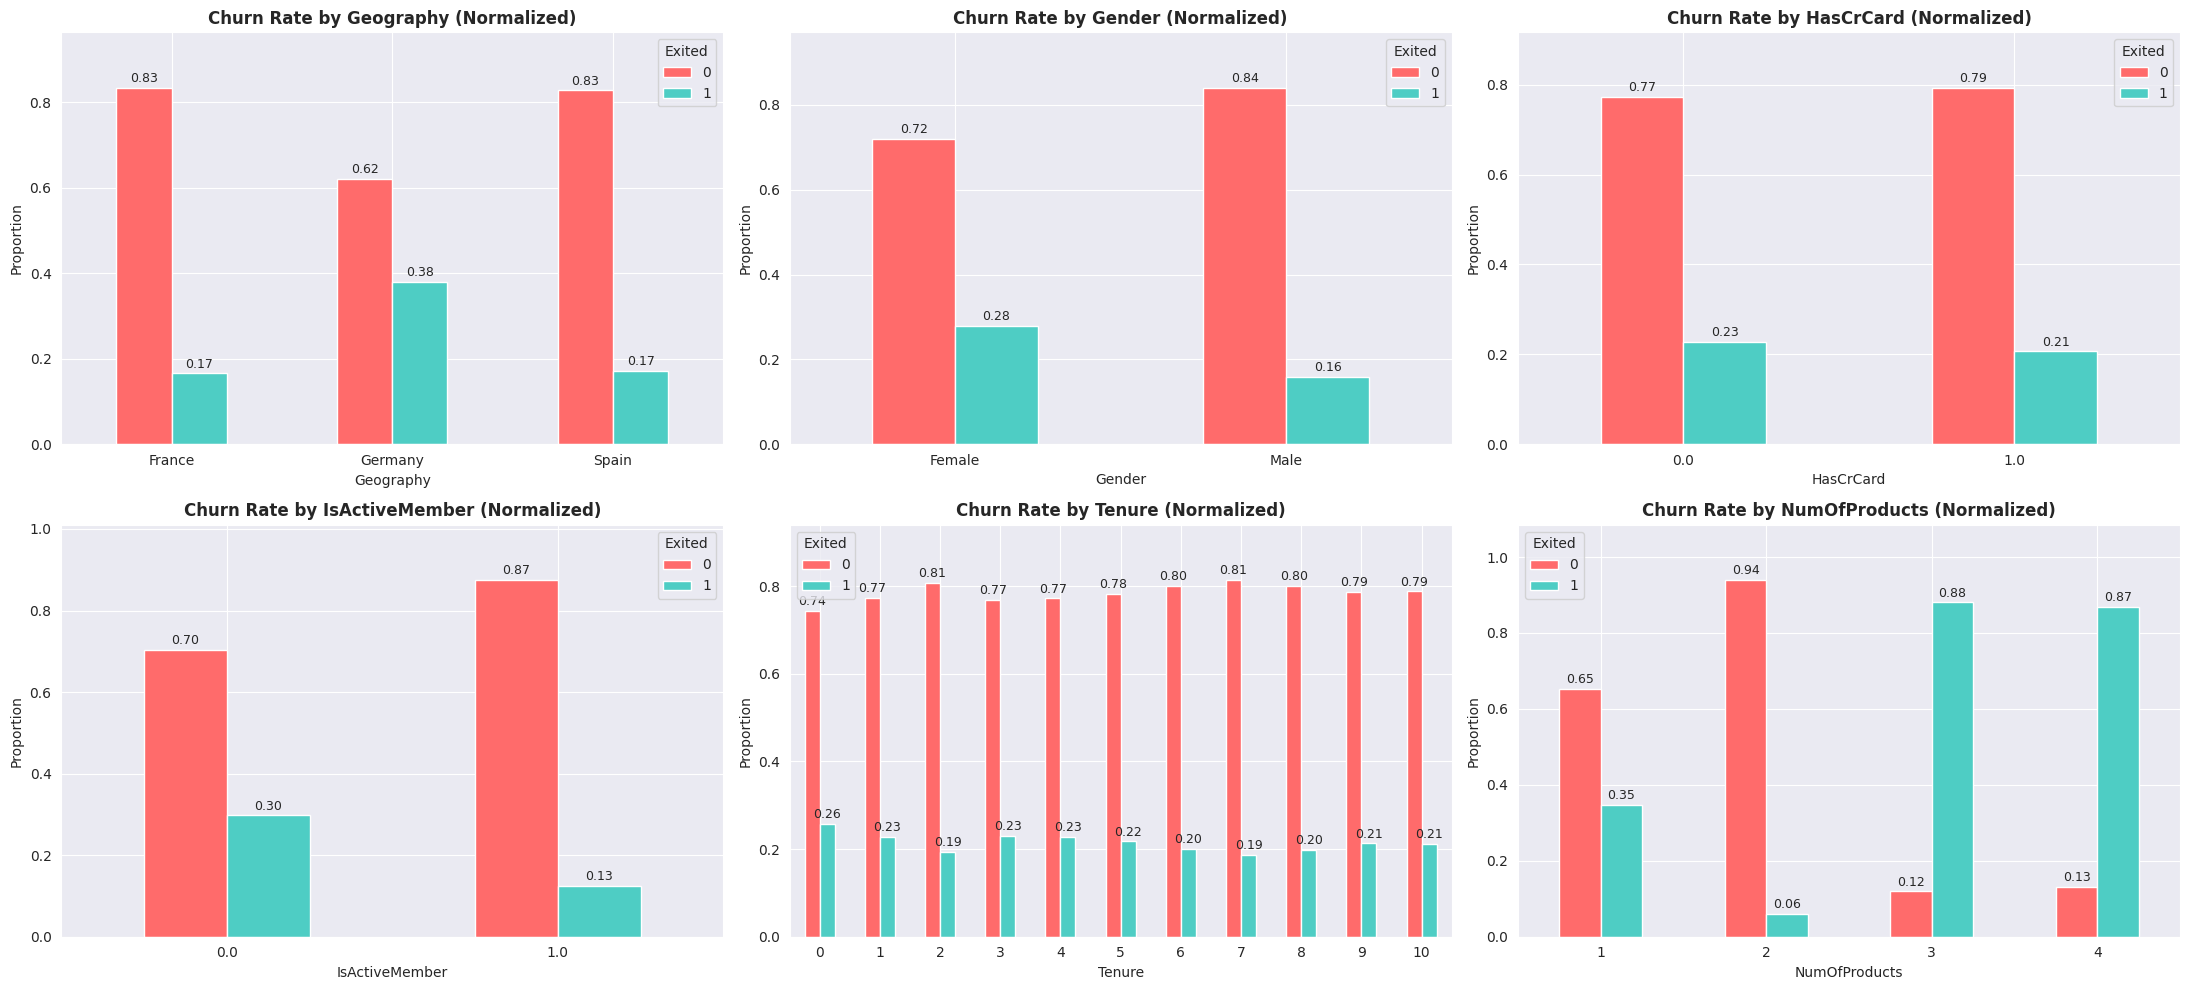

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))

def plot_churn_bar(ax, data, group_col, title):
    rate = data.groupby(group_col)['Exited'].value_counts(normalize=True).unstack()
    bars = rate.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(title,fontweight='bold')
    ax.set_ylabel('Proportion')
    
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=2)
    
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)  

plot_churn_bar(axes[0, 0], x_train, 'Geography',     'Churn Rate by Geography (Normalized)')
plot_churn_bar(axes[0, 1], x_train, 'Gender',        'Churn Rate by Gender (Normalized)')
plot_churn_bar(axes[0, 2], x_train, 'HasCrCard',     'Churn Rate by HasCrCard (Normalized)')
plot_churn_bar(axes[1, 0], x_train, 'IsActiveMember','Churn Rate by IsActiveMember (Normalized)')
plot_churn_bar(axes[1, 1], x_train, 'Tenure',        'Churn Rate by Tenure (Normalized)')
plot_churn_bar(axes[1, 2], x_train, 'NumOfProducts', 'Churn Rate by NumOfProducts (Normalized)')

plt.tight_layout()
plt.show()

***Geography***
- Germany has the highest churn rate at **38%**, more than double that of France and Spain (both at **17%**)
- France and Spain behave similarly and represent lower-risk segments

***Gender***
- Female customers churn at **28%** compared to **16%** for males
- Gender carries a moderate but meaningful signal worth keeping in the model

***Credit Card Ownership (HasCrCard)***
- Churn rates are nearly identical between cardholders and non-cardholders (**21% vs. 23%**)
- This feature adds little predictive value and could be dropped

***Active Membership (IsActiveMember)***
- Inactive members churn at **30%** while active members churn at only **13%**
- One of the strongest churn signals in the dataset

***Tenure***
- Churn rates remain flat across all tenure groups, ranging between **19–26%** with no clear trend
- Tenure does not appear to be a meaningful differentiator on its own

***Number of Products (NumOfProducts)***
- Customers with **2 products have the lowest churn at just 6%**
- Churn spikes dramatically for customers with **3 or 4 products (87–88%)**
- Highly predictive but non-linear — will need careful encoding

### Key Takeaways
- **IsActiveMember** and **NumOfProducts** are the strongest churn signals in the dataset
- **Germany** and **inactive members** are the highest-risk segments
- **Female customers** churn notably more than males — worth investigating further
- **HasCrCard** and **Tenure** show weak signal and may not add much without further feature engineering
- Retention strategies should prioritize re-engaging inactive members, the German market, and customers holding 3+ products

In [8]:
def transform_geo_gender(df):
    df['Germany'] = (df['Geography'] == "Germany").astype(int)
    df['InActive'] = np.where((df['IsActiveMember'].astype(int)) ==1, 0,1)
    df['InActive+Germany'] = df['Germany'] * df['InActive']

    df['Female'] = (df['Gender'] == 'Female').astype(int)
    df = df.drop(['Geography', 'IsActiveMember', 'Gender', 'Tenure', 'HasCrCard'], axis=1)
    return df

In [9]:
x_train = transform_geo_gender(x_train)
x_valid = transform_geo_gender(x_valid)
test = transform_geo_gender(test)
x_train.sample(5)

,CreditScore,Age,Balance,NumOfProducts,EstimatedSalary,Exited,Germany,InActive,InActive+Germany,Female
154706,633,42.0,0.00,1,58907.08,1,0,0,0,1
112544,613,34.0,128927.13,1,161479.85,0,1,0,0,0
47376,653,44.0,0.00,2,164966.27,1,0,1,0,1
10824,588,33.0,0.00,1,102520.07,0,0,1,0,1
29481,632,47.0,0.00,1,132973.21,1,0,1,0,1


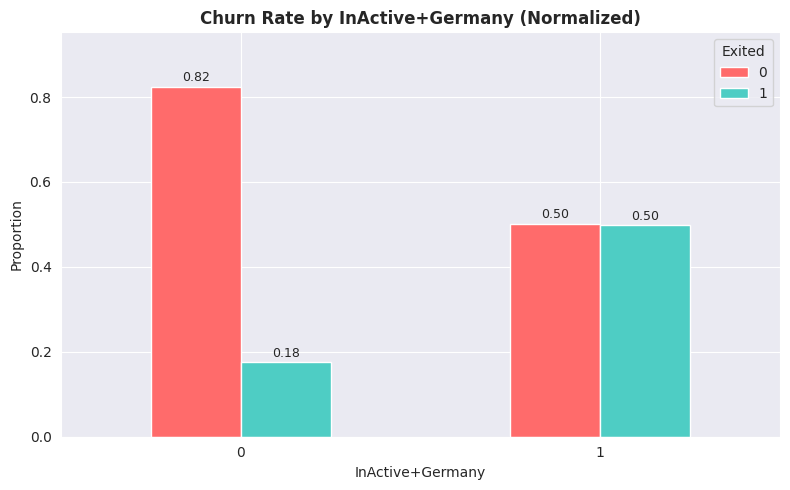

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_churn_bar(ax, x_train, 'InActive+Germany', 'Churn Rate by InActive+Germany (Normalized)')
plt.tight_layout()
plt.show()

## Feature Analysis: `InActive + Germany` vs `Exited`

The bar chart compares the churn rate (`Exited`) across two groups of the interaction feature `InActive+Germany`.

- **Group 0** (not both inactive and from Germany): ~82% of customers were **retained** and only ~18% **churned** — indicating a relatively low churn risk.
- **Group 1** (inactive customers located in Germany): the churn rate rises sharply to ~50%, meaning half of this group left the bank.

This suggests that customers who are **both inactive and based in Germany** are significantly more likely to churn, with a churn rate approximately **2.7x higher** than the rest of the customer base. The `InActive+Germany` interaction term therefore appears to be a **strong predictor** of customer churn and should be considered an important feature in the predictive model.

In [11]:
def create_InActive_x_HighProduct(df):
    df['HighProduct'] = (df['NumOfProducts'] >= 3).astype(int)
    df['InActive_x_HighProduct'] = df['InActive'] * df['HighProduct']
    return df

x_train = create_InActive_x_HighProduct(x_train)
x_valid = create_InActive_x_HighProduct(x_valid)
test = create_InActive_x_HighProduct(test)

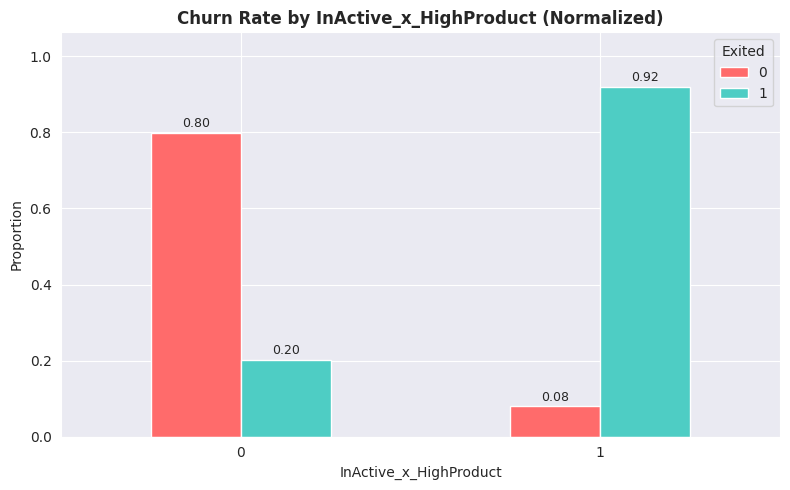

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

plot_churn_bar(ax, x_train, 'InActive_x_HighProduct', 'Churn Rate by InActive_x_HighProduct (Normalized)')
plt.tight_layout()
plt.show()

## Feature Analysis: `InActive_x_HighProduct` vs `Exited`
The bar chart compares the churn rate (`Exited`) across two groups of the interaction feature `InActive_x_HighProduct`.
- **Group 0** (customers who are either active, or hold fewer than 3 products): ~80% were **retained** and only ~20% **churned** — indicating a relatively average churn risk.
- **Group 1** (inactive customers who hold 3 or more products): the churn rate skyrockets to **92%**, meaning nearly all customers in this group left the bank.

This suggests that customers who are **both inactive and hold 3+ products** represent the single highest-risk segment in the dataset, with a churn rate approximately **4.6x higher** than the rest of the customer base. The `InActive_x_HighProduct` interaction term therefore appears to be an **exceptionally strong predictor** of customer churn and should be treated as a priority feature in the predictive model.

In [13]:
def create_Female_x_Germany(df):
    df['Female_x_Germany'] = df['Female'] * df['Germany']
    return df

x_train = create_Female_x_Germany(x_train)
x_valid = create_Female_x_Germany(x_valid)
test = create_Female_x_Germany(test)

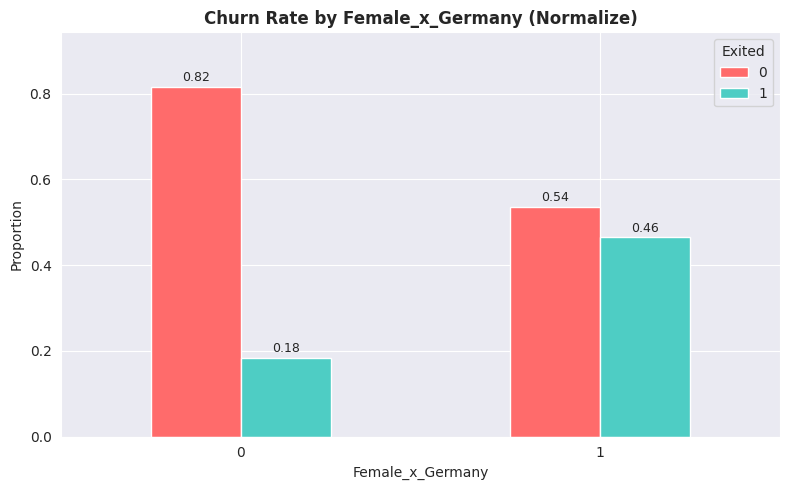

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

plot_churn_bar(ax, x_train, 'Female_x_Germany', 'Churn Rate by Female_x_Germany (Normalize)')
plt.tight_layout()
plt.show()

## Feature Analysis: `Female_x_Germany` vs `Exited`
The bar chart compares the churn rate (`Exited`) across two groups of the interaction feature `Female_x_Germany`.
- **Group 0** (customers who are either male, or not based in Germany): ~82% were **retained** and only ~18% **churned** — indicating a relatively low churn risk.
- **Group 1** (female customers located in Germany): the churn rate rises sharply to **46%**, meaning nearly half of this group left the bank.

This suggests that customers who are **both female and based in Germany** are significantly more likely to churn, with a churn rate approximately **2.6x higher** than the rest of the customer base. The `Female_x_Germany` interaction term therefore appears to be a **strong predictor** of customer churn and should be considered an important feature in the predictive model.

### Age

Text(0.5, 1.0, 'Scatter Plot of Age')

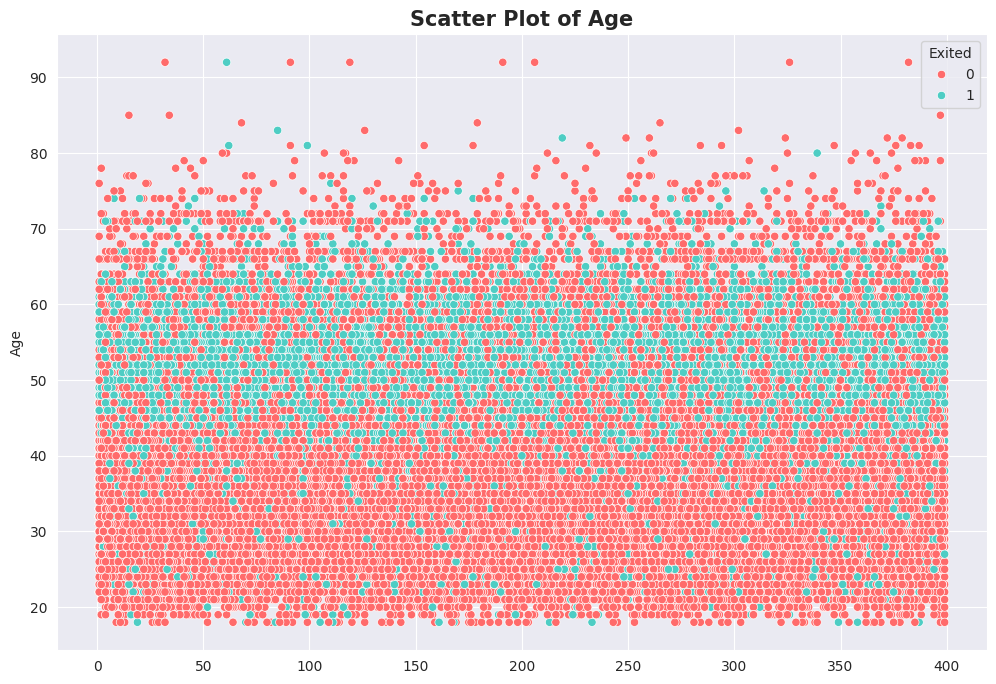

In [15]:
fig, ax = plt.subplots(figsize=(12,8))
sns.scatterplot(data=x_train,x = np.random.randint(1,400,size=x_train.shape[0]),y='Age',hue='Exited')
plt.title('Scatter Plot of Age',fontsize=15,fontweight='bold')

In [16]:
age_label = ['Student', 'Early Career', 'Adults', 'Pre Retirement', 'Near Retirement', 'Retirees']
age_bins = [-1, 25, 35, 45, 55, 65, np.inf]

def transform_age(df):
    df['Age_Bracket'] = pd.cut(df['Age'], bins=age_bins, labels = age_label)
    df.drop('Age', axis=1, inplace=True)
    return df
x_train = transform_age(x_train)
x_valid = transform_age(x_valid)
test = transform_age(test)

/tmp/ipykernel_16/1079755281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = data.groupby(group_col)['Exited'].value_counts(normalize=True).unstack()


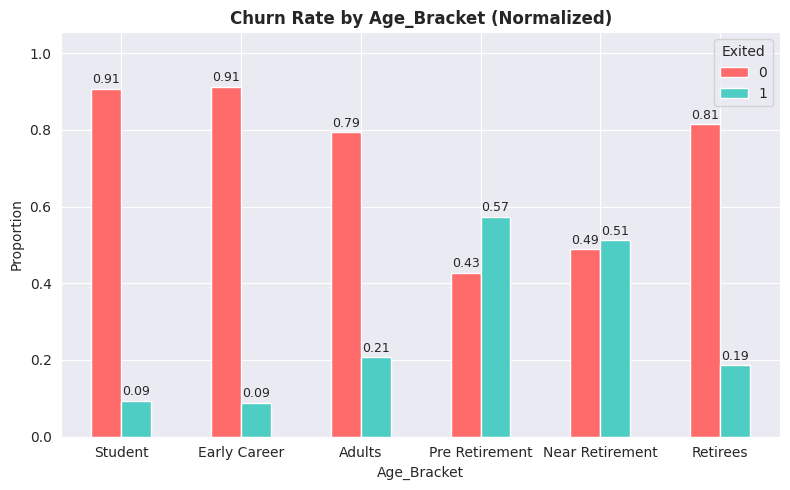

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
plot_churn_bar(ax, x_train, 'Age_Bracket', 'Churn Rate by Age_Bracket (Normalized)')
plt.tight_layout()
plt.show()

## Feature Analysis: `Age_Bracket` vs `Exited`
The bar chart compares the churn rate (`Exited`) across six age bracket groups.
- **Student & Early Career**: both groups have the lowest churn rate at just **9%** — these are the most loyal and stable segments.
- **Adults**: churn rises moderately to **21%**, still below the overall average.
- **Pre-Retirement**: churn spikes significantly to **57%**, making this the highest-risk age group in the dataset.
- **Near Retirement**: churn remains elevated at **51%**, nearly equal to the Pre-Retirement group.
- **Retirees**: churn drops back down to **19%**, suggesting that customers who have already retired tend to stay.

This suggests that customers in the **Pre-Retirement and Near Retirement brackets represent the highest churn risk by age**, while younger customers are significantly more likely to stay. The `Age_Bracket` feature therefore appears to be a **strong predictor** of customer churn, particularly in identifying the mid-to-late career segments as priority targets for retention strategies.

In [18]:
def add_bracket_features(df):
    # CreditScore — FICO Standard
    df['CreditScore_bracket'] = pd.cut(
        df['CreditScore'],
        bins=[349, 579, 669, 739, 850],
        labels=['Poor', 'Fair', 'Good', 'Excellent'],
        include_lowest=True
    )
    
    
    # Balance
    df['Balance_bracket'] = pd.cut(
        df['Balance'],
        bins=[-1, 0, 120000, np.inf],
        labels=['Zero_Balance', 'Mid_Balance', 'High_Balance'],
        include_lowest=True
    )
    # EstimatedSalary
    df['Salary_bracket'] = pd.cut(
        df['EstimatedSalary'],
        bins=[0, 74835, 155616, np.inf],
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )
    return df

x_train = add_bracket_features(x_train)
x_valid   = add_bracket_features(x_valid)
test = add_bracket_features(test)

/tmp/ipykernel_16/1079755281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = data.groupby(group_col)['Exited'].value_counts(normalize=True).unstack()
/tmp/ipykernel_16/1079755281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = data.groupby(group_col)['Exited'].value_counts(normalize=True).unstack()
/tmp/ipykernel_16/1079755281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = data.groupby(g

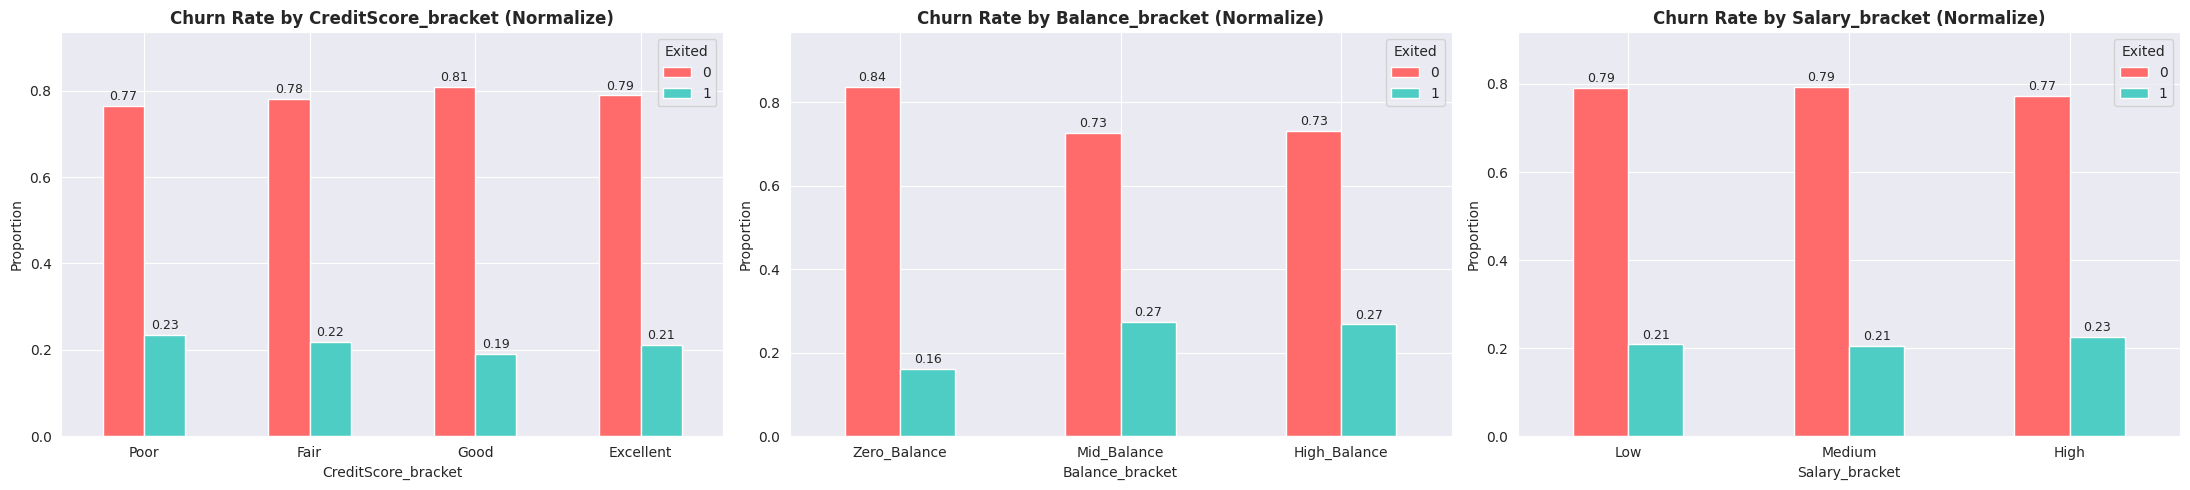

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

plot_churn_bar(axes[0], x_train, 'CreditScore_bracket', 'Churn Rate by CreditScore_bracket (Normalize)')
plot_churn_bar(axes[1], x_train, 'Balance_bracket',     'Churn Rate by Balance_bracket (Normalize)')
plot_churn_bar(axes[2], x_train, 'Salary_bracket',      'Churn Rate by Salary_bracket (Normalize)')

plt.tight_layout()
plt.show()

***CreditScore Bracket (FICO Standard)***
- Churn rates are relatively flat across all credit score groups, ranging between **19–23%**
- Customers with **Good credit churn the least (19%)**, while **Poor credit churns the most (23%)** — but the gap is small
- CreditScore bracket does not appear to be a strong differentiator for churn

***Balance Bracket***
- Customers with **Zero Balance have the lowest churn at 16%**, suggesting they may be less financially engaged but also less likely to leave
- Both **Mid and High Balance groups churn at the same rate (27%)**, noticeably higher than Zero Balance
- Having a non-zero balance appears to be a moderate churn signal, but the amount itself does not matter much beyond that threshold

***Salary Bracket***
- Churn rates are nearly identical across all salary levels — **Low (21%), Medium (21%), High (23%)**
- EstimatedSalary shows **almost no predictive power** for churn and is likely not a useful feature

### Key Takeaways
- **Balance bracket** is the only feature here worth keeping — specifically the Zero vs Non-Zero split
- **CreditScore bracket** has marginal signal at best and may not add much to the model
- **Salary bracket** can likely be dropped entirely, as it shows no meaningful separation across groups

In [20]:
def create_HasBalance_Feature(df):
    df['HasBalance'] = (df['Balance'] > 0).astype(int)
    return df
x_train = create_HasBalance_Feature(x_train)
x_valid = create_HasBalance_Feature(x_valid)
test = create_HasBalance_Feature(test)

In [21]:
def drop_CreditScore_Balance_Salary(df):
    col = ['CreditScore', 'Balance', 'EstimatedSalary', 'CreditScore_bracket', 'Balance_bracket', 'Salary_bracket']
    df = df.drop(col, axis=1)
    return df
x_train = drop_CreditScore_Balance_Salary(x_train)
x_valid = drop_CreditScore_Balance_Salary(x_valid)
test = drop_CreditScore_Balance_Salary(test)

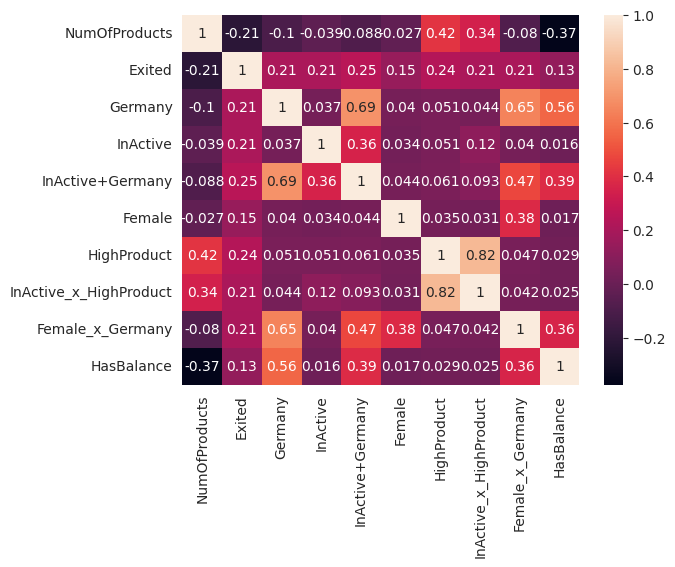

In [22]:
corr = x_train.corr(numeric_only= True)

sns.heatmap(corr, annot=True)
plt.show()

In [23]:

y_train = x_train['Exited']
y_valid = x_valid['Exited']

x_train = x_train.drop(columns=['Exited'])
x_valid = x_valid.drop(columns=['Exited'])



Onehot = OneHotEncoder(sparse_output=False, drop='first')
x_train = Onehot.fit_transform(x_train)
x_valid = Onehot.transform(x_valid)
test    = Onehot.transform(test)

### VIF

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
feature_names = Onehot.get_feature_names_out()
x_train_df = pd.DataFrame(x_train, columns=feature_names)

vif_data = pd.DataFrame()
vif_data["Feature"] = feature_names
vif_data["VIF"] = [
    variance_inflation_factor(x_train_df.values, i)
    for i in range(x_train_df.shape[1])
]

vif_data = vif_data.replace([np.inf, -np.inf], np.nan).dropna(subset=["VIF"])

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

def get_color(v):
    if v < 3:   return "#639922"
    if v < 10:  return "#BA7517"
    return "#A32D2D"

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


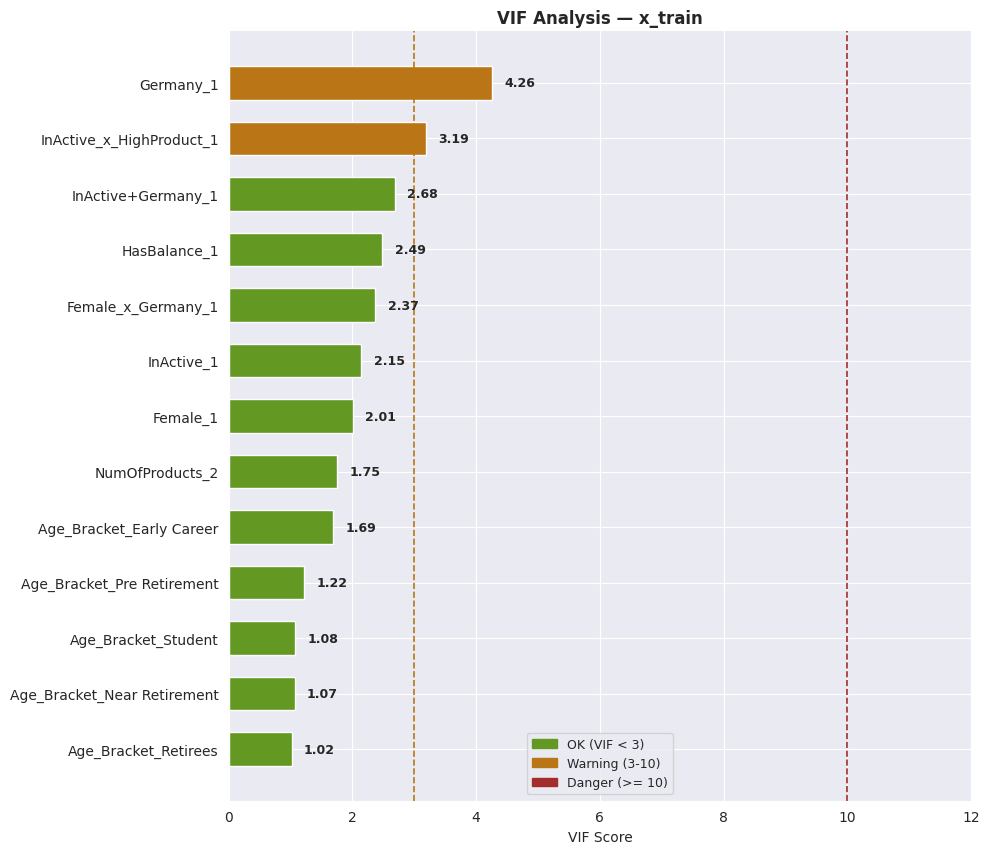

                    Feature      VIF
                  Germany_1 4.261602
   InActive_x_HighProduct_1 3.190202
         InActive+Germany_1 2.681501
               HasBalance_1 2.485497
         Female_x_Germany_1 2.372039
                 InActive_1 2.147568
                   Female_1 2.008072
            NumOfProducts_2 1.747962
   Age_Bracket_Early Career 1.686703
 Age_Bracket_Pre Retirement 1.222775
        Age_Bracket_Student 1.080154
Age_Bracket_Near Retirement 1.065282
       Age_Bracket_Retirees 1.018785


In [25]:
colors = vif_data["VIF"].apply(get_color)

fig, ax = plt.subplots(figsize=(10, max(4, len(vif_data) * 0.55 + 1.5)))
bars = ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors, height=0.6)
ax.axvline(x=3,  color="#BA7517", linestyle="--", linewidth=1.2, label="Threshold 3")
ax.axvline(x=10, color="#A32D2D", linestyle="--", linewidth=1.2, label="Threshold 10")

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

patches = [
    mpatches.Patch(color="#639922", label="OK (VIF < 3)"),
    mpatches.Patch(color="#BA7517", label="Warning (3-10)"),
    mpatches.Patch(color="#A32D2D", label="Danger (>= 10)"),
]
ax.legend(handles=patches, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("VIF Score")
ax.set_title("VIF Analysis — x_train", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
vif_max = vif_data["VIF"].replace([np.inf, -np.inf], np.nan).max()
ax.set_xlim(0, max(vif_max * 1.2, 12) if np.isfinite(vif_max) else 12)
plt.tight_layout()
plt.show()

# --- ดู Feature ที่มีปัญหา ---
print(vif_data.to_string(index=False))

***Germany_1 (VIF = 4.26) — Warning***
- Highest VIF in the dataset, elevated because `Germany_1` shares information with two interaction terms built from it — `InActive+Germany_1` and `Female_x_Germany_1`
- Since those interaction terms already capture the Germany effect, **dropping `Germany_1` is a reasonable option** and should not result in meaningful information loss

***InActive_x_HighProduct_1 (VIF = 3.19) — Warning***
- Sits just above the warning threshold but remains far from the danger zone (VIF < 10)
- This interaction term is expected to carry **strong predictive signal toward the target**, so dropping it is not recommended — the marginal multicollinearity is an acceptable trade-off

***Remaining Features (VIF 1.02 – 2.68) — OK***
- All 11 remaining features fall comfortably below VIF = 3, indicating **no multicollinearity concern**
- Includes `InActive+Germany_1`, `HasBalance_1`, `Female_x_Germany_1`, `InActive_1`, `Female_1`, `NumOfProducts_2`, and all `Age_Bracket` dummies

### Key Takeaways
- **No severe multicollinearity detected** — all VIF values are well below the critical threshold of 10
- **Germany_1** is the only candidate for dropping, as its information is already captured by interaction terms
- **InActive_x_HighProduct_1** should be retained despite the warning-level VIF, given its expected predictive strength
- **Next step:** Train two model versions — with and without `Germany_1` — then compare AUC to confirm whether dropping it is beneficial

In [26]:
cols_to_drop = ["Germany_1"]

x_train_v2 = pd.DataFrame(x_train, columns=feature_names).drop(columns=cols_to_drop)
x_valid_v2 = pd.DataFrame(x_valid, columns=feature_names).drop(columns=cols_to_drop)
test_v2    = pd.DataFrame(test,    columns=feature_names).drop(columns=cols_to_drop)

In [27]:
from sklearn.linear_model import LogisticRegression
lr1 = LogisticRegression(max_iter=500, class_weight='balanced').fit(x_train, y_train)

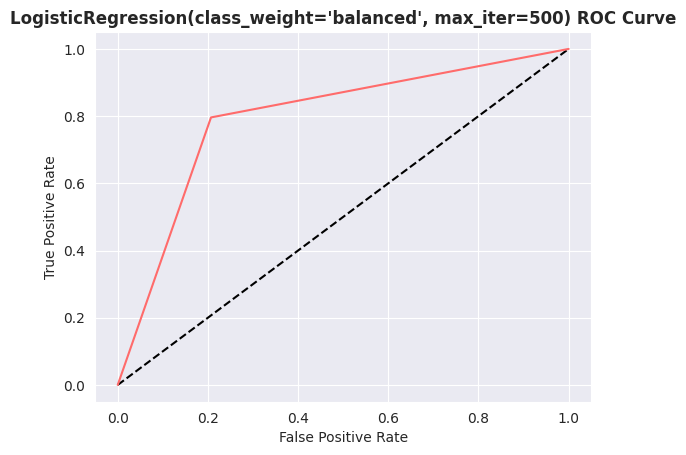

0.8742991537248459


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix
def plot_roc_curve(model, x, y):
    fpr, tpr, thresholds = roc_curve(y, model.predict(x))
    plt.plot([0,1], [0,1], 'k--')
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model} ROC Curve', fontweight='bold')
    plt.show()
plot_roc_curve(lr1, x_valid, y_valid)
print(roc_auc_score(y_valid, lr1.predict_proba(x_valid)[:, 1]))

In [29]:
print(classification_report(y_valid, lr1.predict(x_valid)))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86     26052
           1       0.51      0.80      0.62      6955

    accuracy                           0.79     33007
   macro avg       0.72      0.79      0.74     33007
weighted avg       0.85      0.79      0.81     33007



### Without ***Germany_1***

In [30]:
lr2 = LogisticRegression(max_iter=500, class_weight='balanced').fit(x_train_v2, y_train)

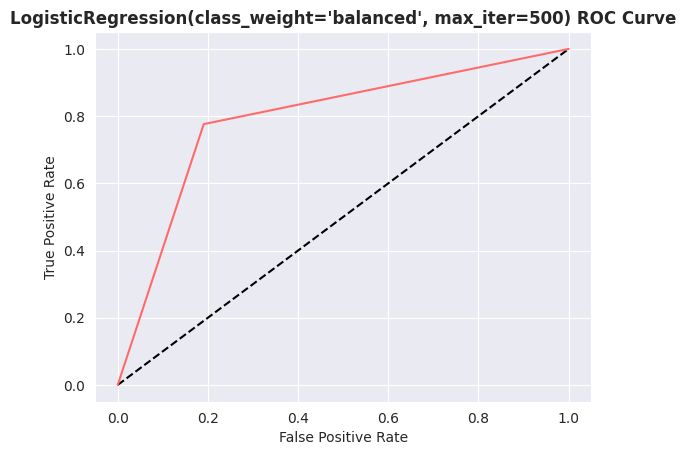

0.8700548193001819


In [31]:
plot_roc_curve(lr2, x_valid_v2, y_valid)
print(roc_auc_score(y_valid, lr2.predict_proba(x_valid_v2)[:, 1]))

#### Key Takeaways

- **`Germany_1` should be retained** — even a small performance gain is worth keeping at no additional cost
- **No further training is planned** — ROC-AUC ~0.87 is a strong baseline result for Logistic Regression and further iterations are unlikely to yield meaningful improvement
- **This model serves as a solid reference point** if more complex models are explored in the future

In [32]:
submission = pd.DataFrame({
    'id'    : id_test,
    'Exited': lr1.predict_proba(test)[:, 1]
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

       id    Exited
0  165034  0.066443
1  165035  0.947403
2  165036  0.168737
3  165037  0.683585
4  165038  0.814870
